In [1]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/.julia/dev/DiffusionEvolution`


In [2]:
using Revise

In [3]:
using DiffusionEvolution, PyPlot, LinearAlgebra, Statistics, JLD2

Precompiling DiffusionEvolution
  ✓ DiffusionEvolution
  1 dependency successfully precompiled in 3 seconds. 122 already precompiled.


In [4]:
const de = DiffusionEvolution

DiffusionEvolution

In [5]:
import PyPlot.subplots
subplots(x, y, d) = subplots(x, y, figsize=(y*d, x*d))

subplots (generic function with 2 methods)

In [6]:
d = 10
nsamples = 1000
T = 50

50

In [84]:
λ_diag = 1.0
λ_skew = 0.1
θ0 = fill(0.0, d)
θ1 = fill(5.0, d)
γ = 0.1
J, θ, min_eigv, max_eigv = random_pars(λ_diag, λ_skew, θ0, θ1, d=d);

In [85]:
min_eigv, max_eigv

(0.749717549452968, 1.501843573076779)

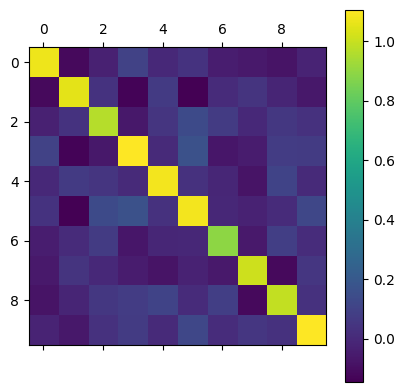

PyObject <matplotlib.colorbar.Colorbar object at 0x795940be1000>

In [86]:
matshow(inv(J))
colorbar()

In [87]:
θ |> norm

17.727700262730227

In [88]:
x = simulate_ou_process(J, θ, γ, nsamples=nsamples, T=T);

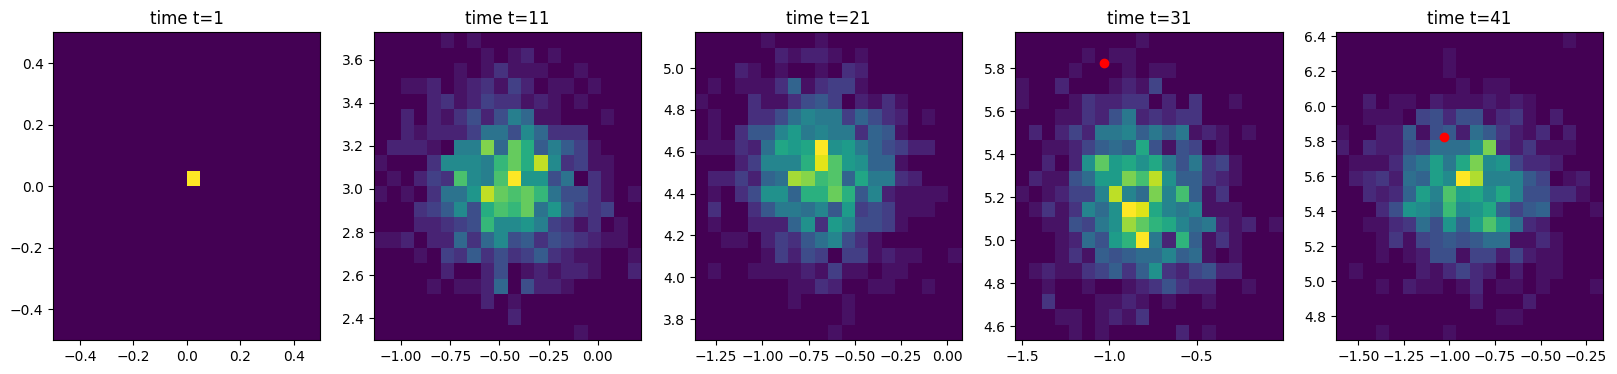

In [89]:
tpoints = 1:10:T
fig, ax = subplots(1, length(tpoints), 4)
for t in eachindex(tpoints)
    ax[t].hist2d(x[1,:,tpoints[t]], x[2,:,tpoints[t]], bins=20)
    ax[t].scatter(θ[1], θ[2], marker="o", color="red")
    ax[t].set_title("time t=$(tpoints[t])")
end

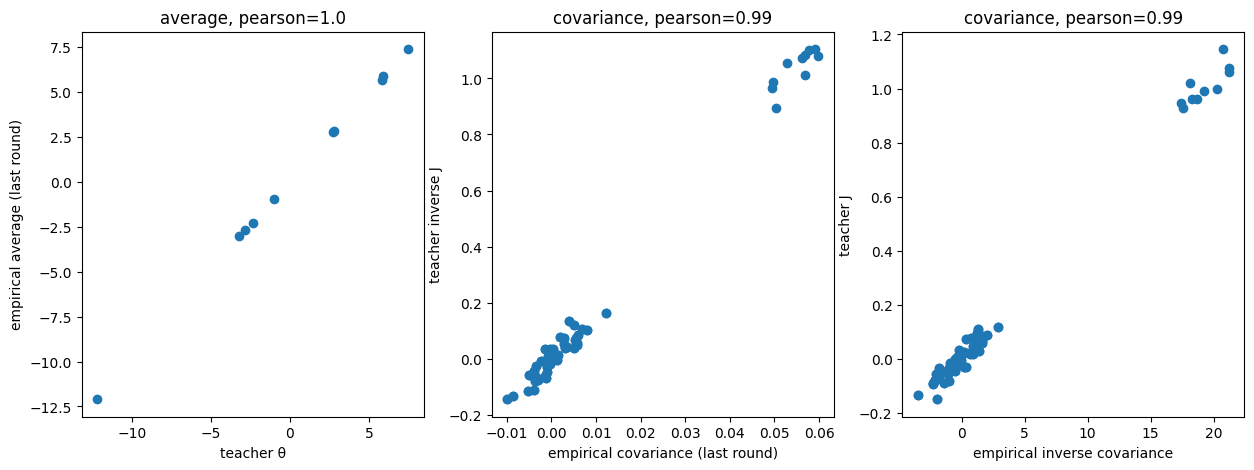

PyObject Text(0.5, 1.0, 'covariance, pearson=0.99')

In [90]:
fig, ax = subplots(1,3,5)
μ_eq = mean(x[:,:,end], dims=2)
Σ_eq = ((x[:,:,end] .- μ_eq)*(x[:,:,end] .- μ_eq)')./nsamples

ax[1].scatter(θ, μ_eq)
ax[1].set_xlabel("teacher θ")
ax[1].set_ylabel("empirical average (last round)")
rho_theta = cor(vec(θ), vec(μ_eq))
ax[1].set_title("average, pearson=$(round(rho_theta, digits=2))")


ax[2].scatter(vec(Σ_eq), vec(inv(J)))
ax[2].set_xlabel("empirical covariance (last round)")
ax[2].set_ylabel("teacher inverse J")
rho_sigma = cor(vec(Σ_eq), vec(inv(J)))
ax[2].set_title("covariance, pearson=$(round(rho_sigma, digits=2))")

ax[3].scatter(vec(inv(Σ_eq)), vec(J))
ax[3].set_xlabel("empirical inverse covariance")
ax[3].set_ylabel("teacher J")
rho_J = cor(vec(inv(Σ_eq)), vec(J))
ax[3].set_title("covariance, pearson=$(round(rho_J, digits=2))")

In [91]:
counts = ones(nsamples, T) ./ nsamples
deltas = fill(1,T)
data = collect_data(x, counts, deltas);

In [93]:
l_values, x_opt, status = learn_nlopt(data, initialize=T, λ=0.1, prior=0.0, ftol_rel=1e-7)

(-13.816502079889693, [99.15588444700381, 6.981929129723863, 83.34982919017526, -0.21370164193782196, -3.75079090179446, 87.64601733210242, -10.767078445340875, 32.25390399286388, -9.523440598859672, 55.895346490916715  …  -0.8196710972969182, 5.1249721036086875, 5.6555208506097205, -2.457650838097217, 2.7688227764873234, -2.420101130248222, 2.810886523805112, 6.848072628241622, -11.509741798738697, -2.0579312306614654], :FTOL_REACHED)

In [68]:
l_values, x_opt = learn_gd(data, initialize=T, epochs=(1000,), η=(0.01,), prior=0.01, progress=true)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:56


([297.16606218068193, 232.87795757821, 204.47053975497107, 190.67986796118922, 183.25858905499655, 178.77835921104472, 175.7277265524381, 173.40418019998364, 171.4651959937528, 169.73649571538164  …  9.023661309161927, 9.014107440415549, 9.00455817092422, 8.995013498480988, 8.98547342088281, 8.975937935930563, 8.9664070414294, 8.956880735187962, 8.947359015019178, 8.9378418787395], [15.711923742448635, 1.1162673571807225, 16.687135580978996, -0.5921201051250031, 0.010055670742470475, 15.78297183896343, 1.333964827466668, -0.2553550580110036, -0.13555475984265525, 12.55815505370201  …  1.1550243276456267, 0.31532373861514484, -0.0846509055054526, -0.3483445100660461, 2.095380715026665, 1.1432564056294008, 1.66501337338358, -8.080841137141682, -1.9671235085244492, -3.0689599679796915])

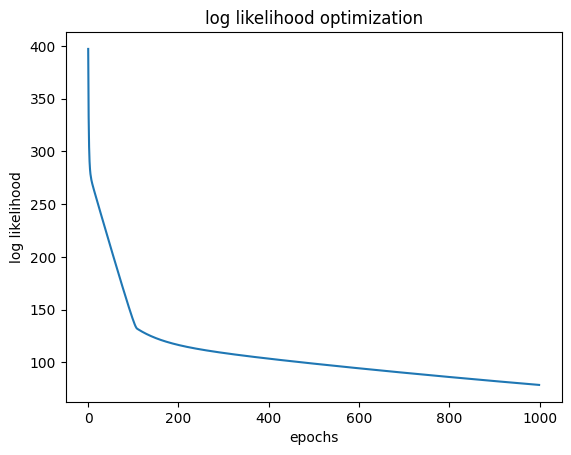

PyObject Text(0.5, 1.0, 'log likelihood optimization')

In [61]:
plot(l_values)
xlabel("epochs")
ylabel("log likelihood")
title("log likelihood optimization")
#yscale(:log);

In [94]:
x_opt

65-element Vector{Float64}:
  99.15588444700381
   6.981929129723863
  83.34982919017526
  -0.21370164193782196
  -3.75079090179446
  87.64601733210242
 -10.767078445340875
  32.25390399286388
  -9.523440598859672
  55.895346490916715
  -2.415974937610834
   2.775254651635884
 -13.63824035389525
   ⋮
  -6.803477171661988
  97.40784110300977
  -0.8196710972969182
   5.1249721036086875
   5.6555208506097205
  -2.457650838097217
   2.7688227764873234
  -2.420101130248222
   2.810886523805112
   6.848072628241622
 -11.509741798738697
  -2.0579312306614654

In [95]:
J_inferred = de.compute_J(x_opt, data.d);

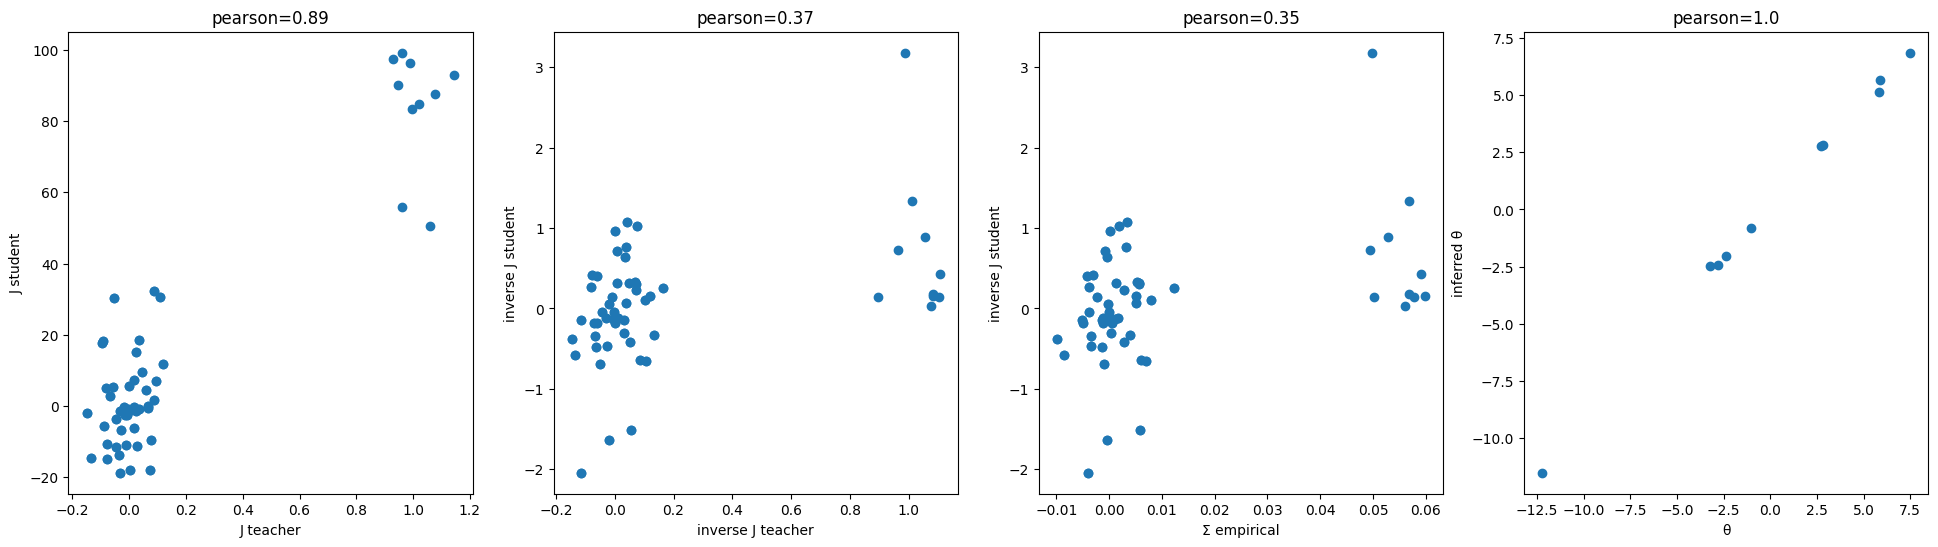

PyObject Text(0.5, 1.0, 'pearson=1.0')

In [96]:
fig, ax = subplots(1, 4, 6)
ax[1].scatter(J, J_inferred)
rho_J = cor(vec(J), vec(J_inferred))
ax[1].set_xlabel("J teacher")
ax[1].set_ylabel("J student")
ax[1].set_title("pearson=$(round(rho_J, digits=2))")

ax[2].scatter(inv(J), inv(J_inferred))
rho_invJ = cor(vec(inv(J)), vec(inv(J_inferred)))
ax[2].set_xlabel("inverse J teacher")
ax[2].set_ylabel("inverse J student")
ax[2].set_title("pearson=$(round(rho_invJ, digits=2))")

ax[3].scatter(Σ_eq, inv(J_inferred))
rho_sigma_invJ = cor(vec(Σ_eq), vec(inv(J_inferred)))
ax[3].set_xlabel("Σ empirical")
ax[3].set_ylabel("inverse J student")
ax[3].set_title("pearson=$(round(rho_sigma_invJ, digits=2))")

ax[4].scatter(θ, x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
rho_theta = cor(vec(θ), x_opt[[de.Hindex(i,data.d) for i in 1:data.d]])
ax[4].set_xlabel("θ")
ax[4].set_ylabel("inferred θ")
ax[4].set_title("pearson=$(round(rho_theta, digits=2))")

In [65]:
de.compute_lambda(J_inferred, x_opt[end])

10×10 Matrix{Float64}:
  8.48983e-6  -1.15109e-6  -2.99786e-6  …  -1.13638e-5  -2.16366e-5
 -1.15109e-6   1.56069e-7   4.06462e-7      1.54075e-6   2.93359e-6
 -2.99786e-6   4.06462e-7   1.05858e-6      4.01268e-6   7.64015e-6
 -9.79455e-6   1.32799e-6   3.45857e-6      1.31102e-5   2.49618e-5
  1.38241e-5  -1.87433e-6  -4.88144e-6     -1.85037e-5  -3.52311e-5
  1.06341e-5  -1.44182e-6  -3.75503e-6  …  -1.42339e-5  -2.71014e-5
  1.00981e-5  -1.36915e-6  -3.56577e-6     -1.35165e-5  -2.57354e-5
 -5.28357e-5   7.16369e-6   1.86569e-5      7.07215e-5   0.000134654
 -1.13638e-5   1.54075e-6   4.01268e-6      1.52106e-5   2.8961e-5
 -2.16366e-5   2.93359e-6   7.64015e-6      2.8961e-5    5.51417e-5